# Trabalho 1 — Processos Estocásticos — Resolução

Caracterização de um sistema **LIT discreto** excitado por processos estocásticos.
A resolução está dividida em:

- **A.** Conjunto `dados_treino_branco.csv` (entrada aproximadamente branca)
- **B.** Conjunto `dados_treino_colorido.csv` (entrada colorida)
- **C.** Conjunto `dados_teste_anomalia.csv` (detecção de anomalia)

Este notebook foca em **produzir resultados**; a redação do relatório fica para depois.

## Configuração e funções auxiliares

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "dados_treino_branco.csv").exists():
    DATA_DIR = PROJECT_ROOT
elif (PROJECT_ROOT.parent / "dados_treino_branco.csv").exists():
    DATA_DIR = PROJECT_ROOT.parent
else:
    DATA_DIR = PROJECT_ROOT / "data"

# Frequência de amostragem: não informada -> assumimos fs = 1 Hz (frequência normalizada)
FS = 1.0

print("DATA_DIR:", DATA_DIR)

DATA_DIR: C:\Users\DELL\Documents\GitHub\stochastic_processes


In [2]:
def load_dataset(filename):
    """Carrega um CSV com colunas n, u, y."""
    df = pd.read_csv(DATA_DIR / filename)
    return df["n"].to_numpy(), df["u"].to_numpy(), df["y"].to_numpy()


def biased_autocorr(x, max_lag=None):
    """Autocorrelação (estimador enviesado) para lags 0..max_lag do sinal centrado."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    full = np.correlate(x, x, mode="full") / n
    mid = n - 1
    if max_lag is None:
        max_lag = n - 1
    return full[mid : mid + max_lag + 1]


def biased_crosscorr(u, y, max_lag):
    """Correlação cruzada R_yu[k] = E{y[n] u[n-k]} (centrada), lags -max_lag..max_lag.

    Nesta convenção, para entrada branca vale R_yu[k] = sigma_u^2 * h[k], de modo que
    a resposta ao impulso causal do sistema aparece nos **lags positivos** (k >= 0).
    """
    u = np.asarray(u, dtype=float) - np.mean(u)
    y = np.asarray(y, dtype=float) - np.mean(y)
    n = len(u)
    full = np.correlate(y, u, mode="full") / n
    mid = n - 1
    lags = np.arange(-max_lag, max_lag + 1)
    return lags, full[mid - max_lag : mid + max_lag + 1]

---
# A. Conjunto `dados_treino_branco.csv`

Amostras: 5000


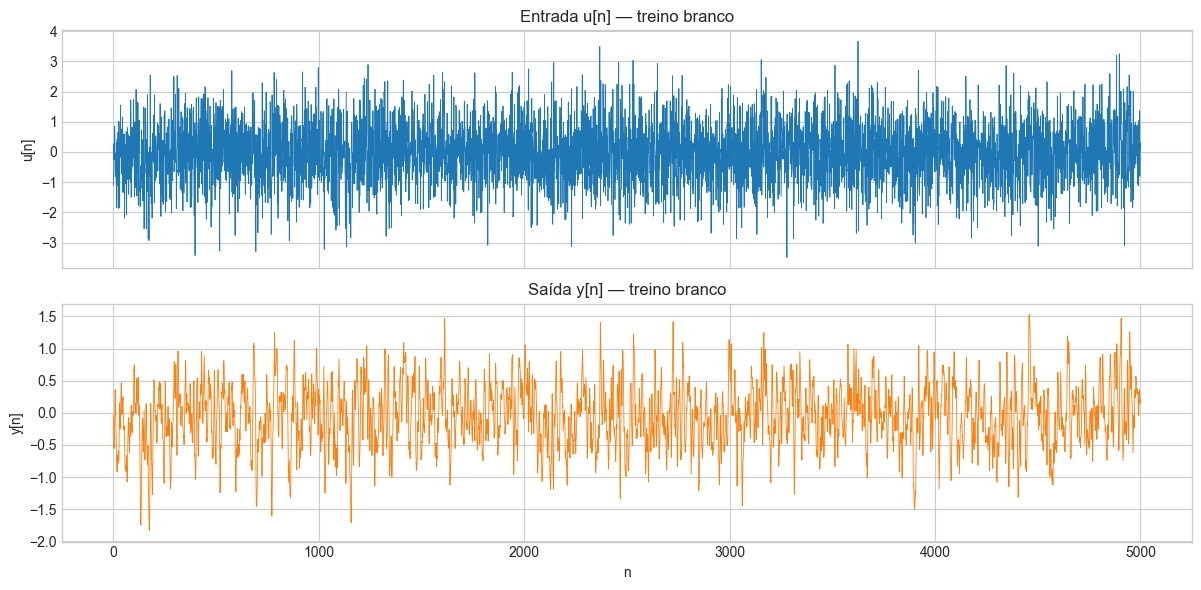

In [3]:
n_a, u_a, y_a = load_dataset("dados_treino_branco.csv")
print(f"Amostras: {len(n_a)}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(n_a, u_a, linewidth=0.6)
axes[0].set_ylabel("u[n]")
axes[0].set_title("Entrada u[n] — treino branco")
axes[1].plot(n_a, y_a, linewidth=0.6, color="C1")
axes[1].set_ylabel("y[n]")
axes[1].set_xlabel("n")
axes[1].set_title("Saída y[n] — treino branco")
plt.tight_layout()
plt.show()

## A.1 — Média, variância e autocorrelação de u[n] e y[n]

In [4]:
stats = pd.DataFrame(
    {
        "sinal": ["u[n]", "y[n]"],
        "média": [u_a.mean(), y_a.mean()],
        "variância": [u_a.var(), y_a.var()],
        "desvio padrão": [u_a.std(), y_a.std()],
        "mínimo": [u_a.min(), y_a.min()],
        "máximo": [u_a.max(), y_a.max()],
    }
)
stats

,sinal,média,variância,desvio padrão,mínimo,máximo
0,u[n],-0.032065,0.988808,0.994388,-3.496153,3.669266
1,y[n],-0.043447,0.231322,0.480960,-1.834390,1.528619


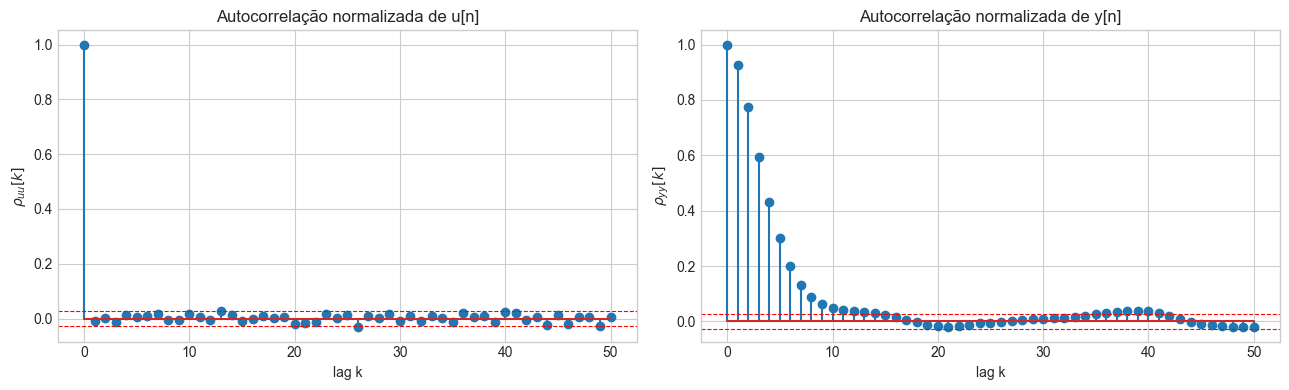

Banda de confiança ~95%: +/- 0.0277
u[n]: fração de |rho| (lags>=1) acima da banda: 0.040
y[n]: fração de |rho| (lags>=1) acima da banda: 0.400


In [5]:
MAX_LAG = 50
lags_pos = np.arange(MAX_LAG + 1)
r_uu = biased_autocorr(u_a, MAX_LAG)
r_yy = biased_autocorr(y_a, MAX_LAG)

# Normalizadas (coeficiente de autocorrelação) para visualização
rho_uu = r_uu / r_uu[0]
rho_yy = r_yy / r_yy[0]

# Banda de confiança ~95% para ruído branco
conf = 1.96 / np.sqrt(len(u_a))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].stem(lags_pos, rho_uu)
axes[0].axhline(conf, color="r", ls="--", lw=0.8)
axes[0].axhline(-conf, color="r", ls="--", lw=0.8)
axes[0].set_title("Autocorrelação normalizada de u[n]")
axes[0].set_xlabel("lag k")
axes[0].set_ylabel(r"$\rho_{uu}[k]$")

axes[1].stem(lags_pos, rho_yy)
axes[1].axhline(conf, color="r", ls="--", lw=0.8)
axes[1].axhline(-conf, color="r", ls="--", lw=0.8)
axes[1].set_title("Autocorrelação normalizada de y[n]")
axes[1].set_xlabel("lag k")
axes[1].set_ylabel(r"$\rho_{yy}[k]$")
plt.tight_layout()
plt.show()

print(f"Banda de confiança ~95%: +/- {conf:.4f}")
print(f"u[n]: fração de |rho| (lags>=1) acima da banda: "
      f"{np.mean(np.abs(rho_uu[1:]) > conf):.3f}")
print(f"y[n]: fração de |rho| (lags>=1) acima da banda: "
      f"{np.mean(np.abs(rho_yy[1:]) > conf):.3f}")

**Leitura esperada:** se `u[n]` é aproximadamente branco, `rho_uu[k] ≈ 0` para `k != 0` (dentro da banda). Já `y[n]` deve apresentar autocorrelação com memória (decaimento), pois é a saída filtrada pelo sistema LIT.

## A.2 — Correlação cruzada entre u[n] e y[n]

Usamos $R_{yu}[k] = E\{y[n]\,u[n-k]\}$. Para entrada branca vale $R_{yu}[k] = \sigma_u^2\, h[k]$, ou seja, a correlação cruzada revela (a menos de escala) a **resposta ao impulso** do sistema, com a parte causal nos **lags positivos** ($k \ge 0$).

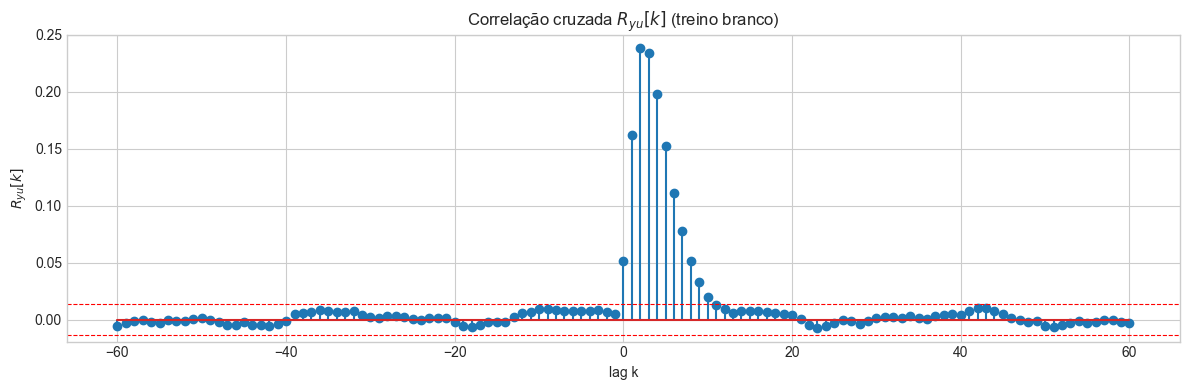

Pico de |R_yu| no lag k = 2
Pico em lag positivo (e ~0 nos lags negativos) indica sistema causal.


In [6]:
CC_LAG = 60
lags_cc, r_yu = biased_crosscorr(u_a, y_a, CC_LAG)

plt.figure(figsize=(12, 4))
plt.stem(lags_cc, r_yu)
plt.axhline(conf * u_a.std() * y_a.std(), color="r", ls="--", lw=0.8)
plt.axhline(-conf * u_a.std() * y_a.std(), color="r", ls="--", lw=0.8)
plt.title(r"Correlação cruzada $R_{yu}[k]$ (treino branco)")
plt.xlabel("lag k")
plt.ylabel(r"$R_{yu}[k]$")
plt.tight_layout()
plt.show()

k_peak = lags_cc[np.argmax(np.abs(r_yu))]
print(f"Pico de |R_yu| no lag k = {k_peak}")
print("Pico em lag positivo (e ~0 nos lags negativos) indica sistema causal.")

## A.3 — PSD de u[n] e y[n] (método de Welch)

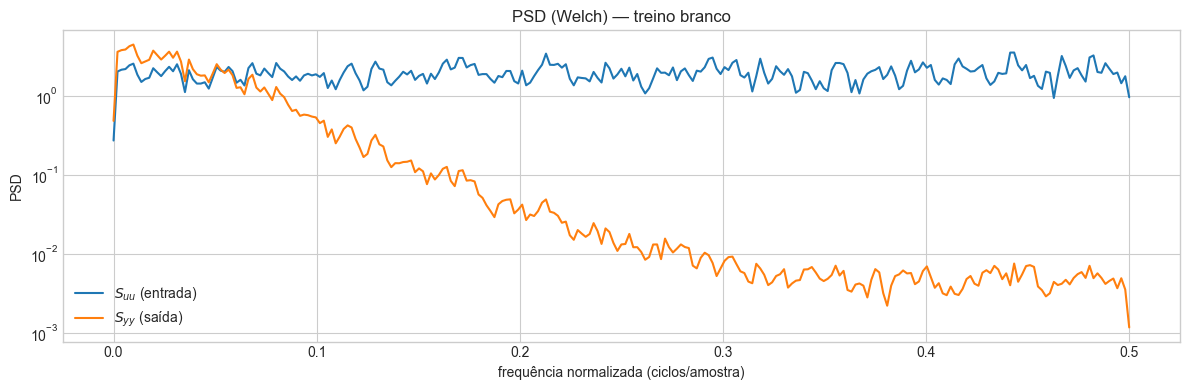

S_uu aproximadamente plana? razão max/min = 13.01


In [7]:
NPERSEG = 512
f_u, Puu = signal.welch(u_a, fs=FS, nperseg=NPERSEG)
f_y, Pyy = signal.welch(y_a, fs=FS, nperseg=NPERSEG)

plt.figure(figsize=(12, 4))
plt.semilogy(f_u, Puu, label=r"$S_{uu}$ (entrada)")
plt.semilogy(f_y, Pyy, label=r"$S_{yy}$ (saída)", color="C1")
plt.title("PSD (Welch) — treino branco")
plt.xlabel("frequência normalizada (ciclos/amostra)")
plt.ylabel("PSD")
plt.legend()
plt.tight_layout()
plt.show()

print(f"S_uu aproximadamente plana? razão max/min = {Puu.max() / Puu.min():.2f}")

**Leitura esperada:** `S_uu` aproximadamente plana (entrada branca). `S_yy` deve revelar o ganho do sistema em função da frequência (regiões de passagem e atenuação).

## A.4 — Espectro cruzado entre u[n] e y[n]

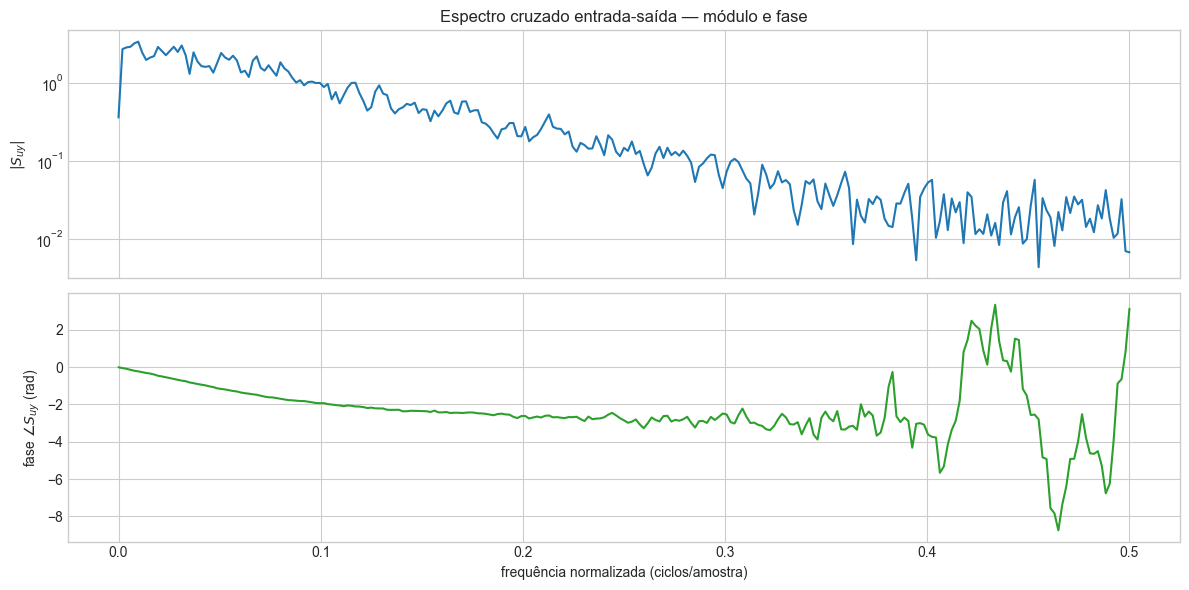

In [8]:
f_c, Suy = signal.csd(u_a, y_a, fs=FS, nperseg=NPERSEG)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].semilogy(f_c, np.abs(Suy))
axes[0].set_ylabel(r"$|S_{uy}|$")
axes[0].set_title("Espectro cruzado entrada-saída — módulo e fase")
axes[1].plot(f_c, np.unwrap(np.angle(Suy)), color="C2")
axes[1].set_ylabel(r"fase $\angle S_{uy}$ (rad)")
axes[1].set_xlabel("frequência normalizada (ciclos/amostra)")
plt.tight_layout()
plt.show()

## A.5 — Coerência entrada-saída

$$\gamma_{uy}^2(e^{j\omega}) = \frac{|S_{uy}(e^{j\omega})|^2}{S_{uu}(e^{j\omega})\, S_{yy}(e^{j\omega})}$$

Valores próximos de 1 indicam relação linear confiável naquela frequência.

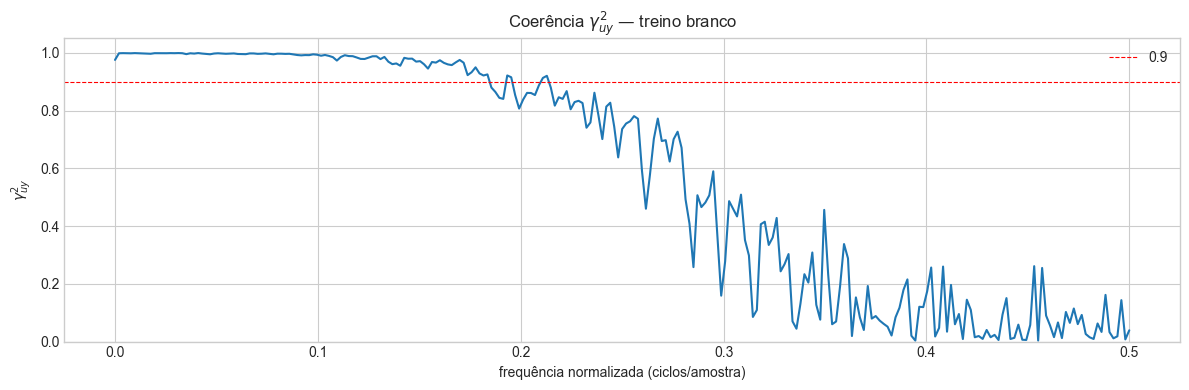

Coerência média: 0.584
Fração de frequências com coerência > 0.9: 0.385


In [9]:
f_coh, coh = signal.coherence(u_a, y_a, fs=FS, nperseg=NPERSEG)

plt.figure(figsize=(12, 4))
plt.plot(f_coh, coh)
plt.axhline(0.9, color="r", ls="--", lw=0.8, label="0.9")
plt.title(r"Coerência $\gamma_{uy}^2$ — treino branco")
plt.xlabel("frequência normalizada (ciclos/amostra)")
plt.ylabel(r"$\gamma_{uy}^2$")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Coerência média: {coh.mean():.3f}")
print(f"Fração de frequências com coerência > 0.9: {np.mean(coh > 0.9):.3f}")

## A.6 — Resposta em frequência por dois métodos

Conforme as fórmulas do material:

- **Método 1 (só módulo):** $|\hat{H}_1(e^{j\omega})| = \sqrt{\dfrac{\hat{S}_{yy}(e^{j\omega})}{\hat{S}_{uu}(e^{j\omega})}}$ — adequado quando a entrada é branca e o ruído de saída não domina.
- **Método 2 (complexo, estimador $H_1$):** $\hat{H}_2(e^{j\omega}) = \dfrac{\hat{S}_{yu}(e^{j\omega})}{\hat{S}_{uu}(e^{j\omega})}$ — fornece módulo **e** fase; deve ser lido junto com a coerência.

> **Convenção do `scipy`:** `signal.csd(u, y)` calcula $\hat{S}_{yu}$ na convenção do material (transformada de $R_{yu}[k]=E\{u[n]\,y[n+k]\}$), pois usa $\overline{U}\,Y$. Verificamos empiricamente que essa escolha produz a fase **correta** (causal), coincidente com a do FIR identificado; usar `csd(y, u)` inverteria o sinal da fase. O módulo é idêntico nos dois casos.

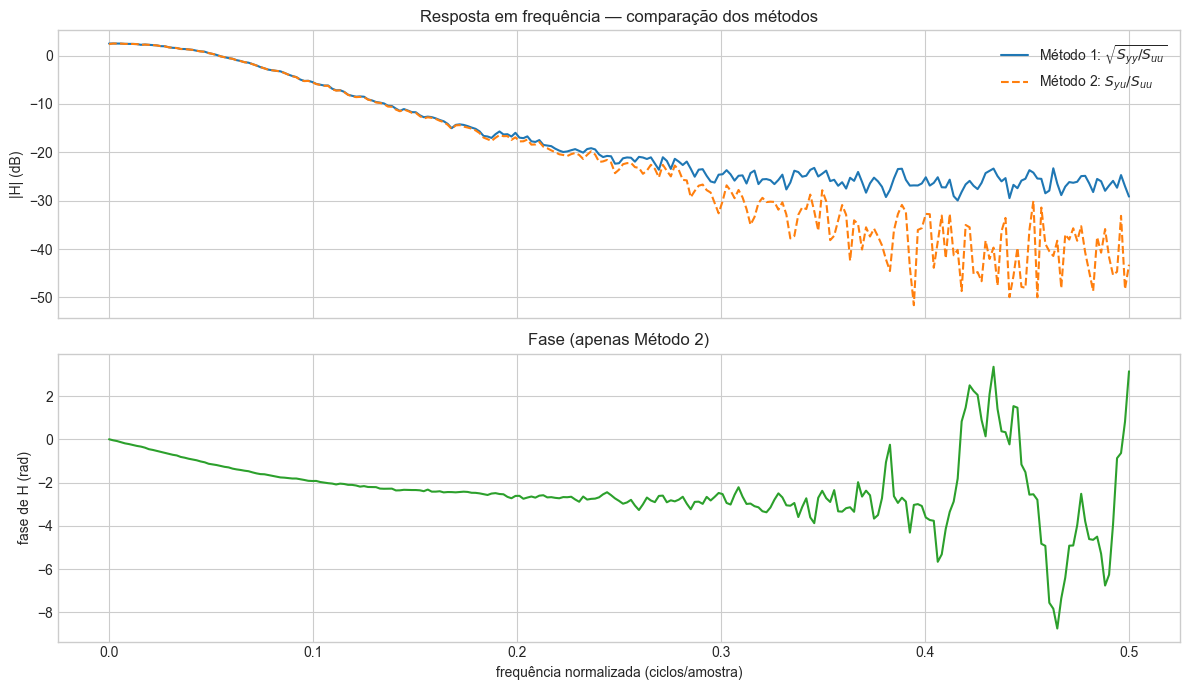

Diferença média de módulo entre métodos: 4.938 dB


In [10]:
# Método 1: |H1| = sqrt(Syy/Suu) (apenas módulo)
H_mag_method1 = np.sqrt(Pyy / Puu)
# Método 2: H2 = Syu/Suu (complexo). No scipy, csd(u, y) == S_yu do material
# (usa conj(U)*Y) e dá a fase causal correta -> Suy aqui é, de fato, S_yu.
H_method2 = Suy / Puu

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(f_u, 20 * np.log10(H_mag_method1), label=r"Método 1: $\sqrt{S_{yy}/S_{uu}}$")
axes[0].plot(f_c, 20 * np.log10(np.abs(H_method2)), label=r"Método 2: $S_{yu}/S_{uu}$", ls="--")
axes[0].set_ylabel("|H| (dB)")
axes[0].set_title("Resposta em frequência — comparação dos métodos")
axes[0].legend()
axes[1].plot(f_c, np.unwrap(np.angle(H_method2)), color="C2")
axes[1].set_ylabel("fase de H (rad)")
axes[1].set_xlabel("frequência normalizada (ciclos/amostra)")
axes[1].set_title("Fase (apenas Método 2)")
plt.tight_layout()
plt.show()

diff_db = 20 * np.log10(H_mag_method1) - 20 * np.log10(np.abs(H_method2))
print(f"Diferença média de módulo entre métodos: {np.mean(np.abs(diff_db)):.3f} dB")

## A.7 — Identificação de modelo LIT (FIR por mínimos quadrados)

Modelo $\hat{y}[n] = \sum_{k=0}^{M-1} h[k]\, u[n-k]$. Estimamos `h` por mínimos quadrados.

In [11]:
def build_fir_regressor(u, M):
    """Matriz de regressão FIR com M taps (inclui atraso 0..M-1)."""
    N = len(u)
    Phi = np.zeros((N, M))
    for k in range(M):
        Phi[k:, k] = u[: N - k]
    return Phi


def fit_eval_skip(u, y, M):
    """Ajusta FIR e avalia descartando as primeiras M-1 amostras (transitório)."""
    Phi = build_fir_regressor(u, M)
    h, *_ = np.linalg.lstsq(Phi[M - 1 :], y[M - 1 :], rcond=None)
    y_hat = Phi @ h
    e = y[M - 1 :] - y_hat[M - 1 :]
    ss_res = np.sum(e ** 2)
    ss_tot = np.sum((y[M - 1 :] - y[M - 1 :].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return h, y_hat, r2


# Escolha da ordem: varre M e observa R^2
orders = [5, 10, 15, 20, 30, 40, 60]
for M in orders:
    _, _, r2 = fit_eval_skip(u_a, y_a, M)
    print(f"M = {M:3d}  ->  R^2 = {r2:.5f}")

M =   5  ->  R^2 = 0.79528
M =  10  ->  R^2 = 0.98910
M =  15  ->  R^2 = 0.99016
M =  20  ->  R^2 = 0.99022
M =  30  ->  R^2 = 0.99022
M =  40  ->  R^2 = 0.99025
M =  60  ->  R^2 = 0.99033


Ordem escolhida M = 30,  R^2 (treino) = 0.99022


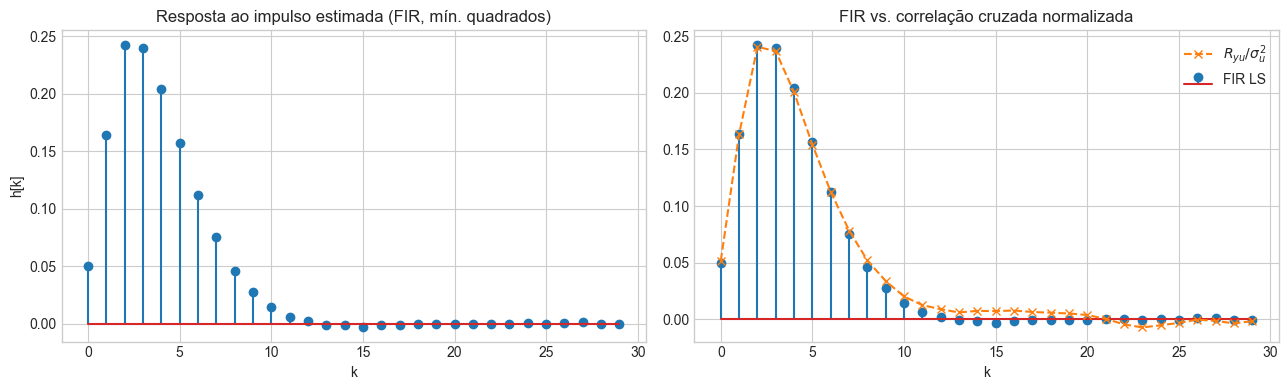

In [12]:
M = 30
h_fir, y_hat_a, r2_a = fit_eval_skip(u_a, y_a, M)
print(f"Ordem escolhida M = {M},  R^2 (treino) = {r2_a:.5f}")

# Comparação: resposta ao impulso estimada vs. R_yu/sigma_u^2 (esperado p/ entrada branca)
h_from_xcorr = r_yu[lags_cc >= 0][:M] / u_a.var()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].stem(np.arange(M), h_fir)
axes[0].set_title("Resposta ao impulso estimada (FIR, mín. quadrados)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("h[k]")
axes[1].stem(np.arange(M), h_fir, linefmt="C0-", markerfmt="C0o", label="FIR LS")
axes[1].plot(np.arange(M), h_from_xcorr, "C1x--", label=r"$R_{yu}/\sigma_u^2$")
axes[1].set_title("FIR vs. correlação cruzada normalizada")
axes[1].set_xlabel("k")
axes[1].legend()
plt.tight_layout()
plt.show()

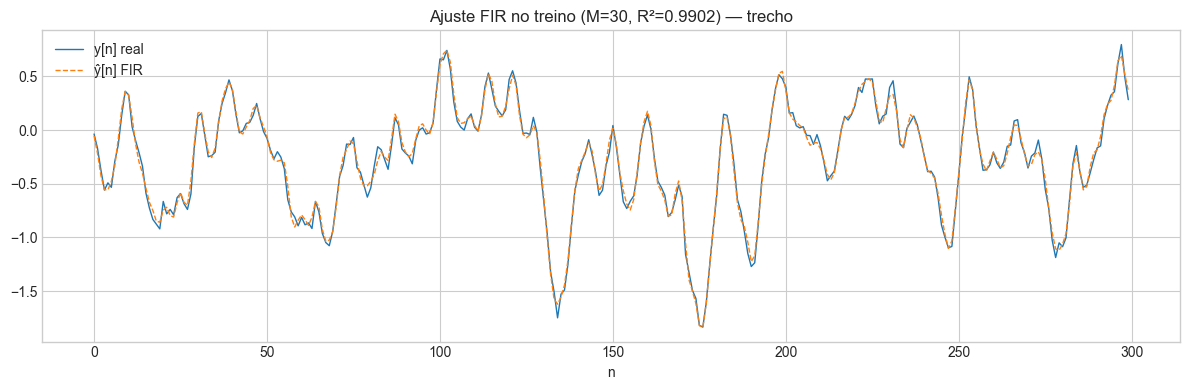

In [13]:
# Ajuste no tempo (trecho)
seg = slice(0, 300)
plt.figure(figsize=(12, 4))
plt.plot(n_a[seg], y_a[seg], label="y[n] real", lw=1.0)
plt.plot(n_a[seg], y_hat_a[seg], label="ŷ[n] FIR", lw=1.0, ls="--")
plt.title(f"Ajuste FIR no treino (M={M}, R²={r2_a:.4f}) — trecho")
plt.xlabel("n")
plt.legend()
plt.tight_layout()
plt.show()

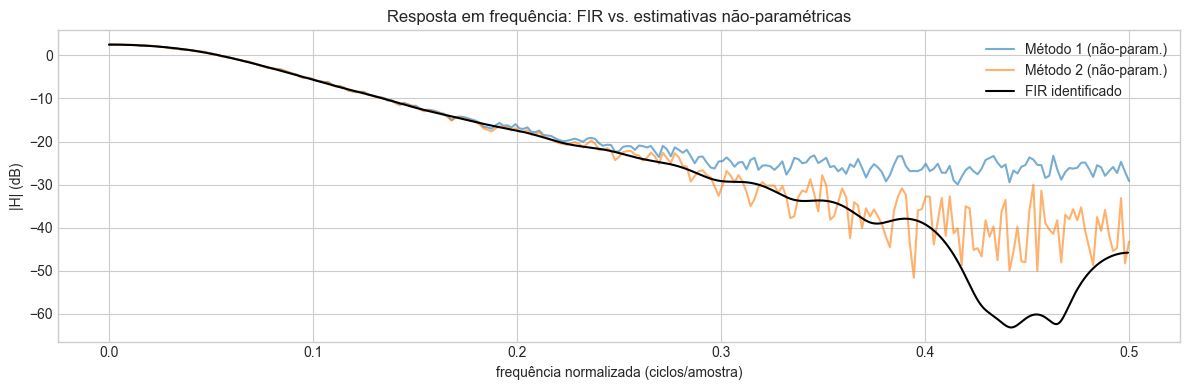

In [14]:
# Resposta em frequência do FIR identificado vs. métodos não-paramétricos
w_fir, H_fir = signal.freqz(h_fir, worN=1024, fs=FS)

plt.figure(figsize=(12, 4))
plt.plot(f_u, 20 * np.log10(H_mag_method1), label="Método 1 (não-param.)", alpha=0.6)
plt.plot(f_c, 20 * np.log10(np.abs(H_method2)), label="Método 2 (não-param.)", alpha=0.6)
plt.plot(w_fir, 20 * np.log10(np.abs(H_fir)), "k", label="FIR identificado")
plt.title("Resposta em frequência: FIR vs. estimativas não-paramétricas")
plt.xlabel("frequência normalizada (ciclos/amostra)")
plt.ylabel("|H| (dB)")
plt.legend()
plt.tight_layout()
plt.show()

## A.8 — Validação com `dados_validacao_branco.csv`

Aplicamos a entrada de validação `uval[n]` ao FIR identificado e comparamos `ŷval[n]` com `yval[n]`.

Validação -> R² = 0.99011 | RMSE = 0.04900 | FIT = 90.05%


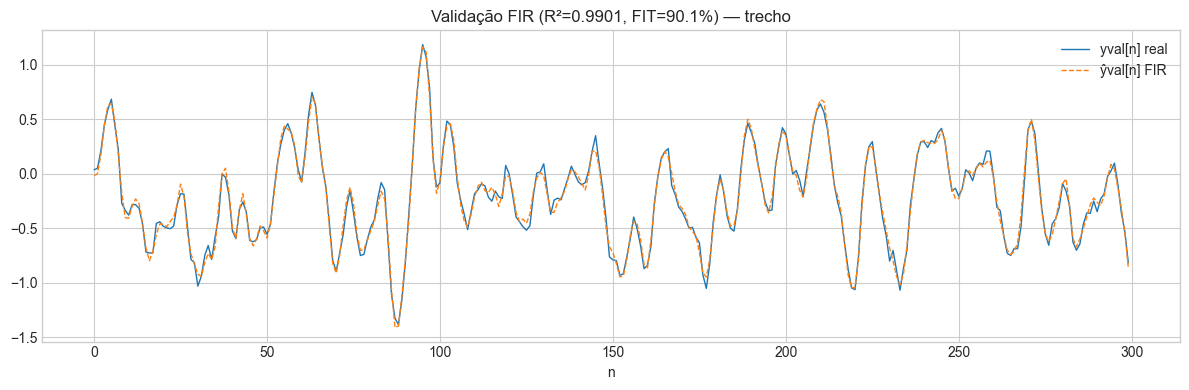

In [15]:
n_v, u_v, y_v = load_dataset("dados_validacao_branco.csv")

y_hat_v = np.convolve(u_v, h_fir)[: len(u_v)]

# Métricas (descartando transitório inicial)
skip = M
e_v = y_v[skip:] - y_hat_v[skip:]
ss_res = np.sum(e_v ** 2)
ss_tot = np.sum((y_v[skip:] - y_v[skip:].mean()) ** 2)
r2_v = 1 - ss_res / ss_tot
rmse_v = np.sqrt(np.mean(e_v ** 2))
# FIT (%) no estilo System Identification Toolbox
fit_v = 100 * (1 - np.linalg.norm(e_v) / np.linalg.norm(y_v[skip:] - y_v[skip:].mean()))

print(f"Validação -> R² = {r2_v:.5f} | RMSE = {rmse_v:.5f} | FIT = {fit_v:.2f}%")

seg = slice(0, 300)
plt.figure(figsize=(12, 4))
plt.plot(n_v[seg], y_v[seg], label="yval[n] real", lw=1.0)
plt.plot(n_v[seg], y_hat_v[seg], label="ŷval[n] FIR", lw=1.0, ls="--")
plt.title(f"Validação FIR (R²={r2_v:.4f}, FIT={fit_v:.1f}%) — trecho")
plt.xlabel("n")
plt.legend()
plt.tight_layout()
plt.show()

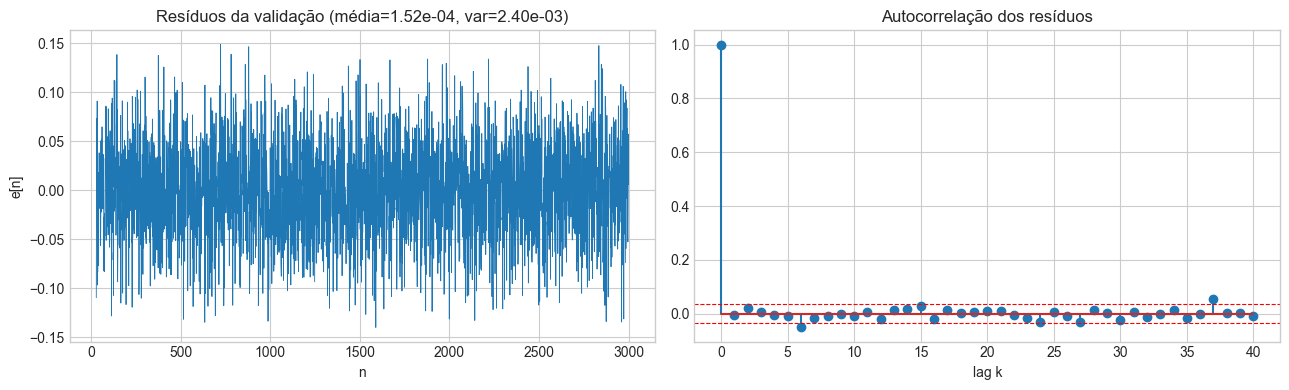

Resíduos ~ brancos e de baixa variância indicam bom modelo.


In [16]:
# Resíduos da validação
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(n_v[skip:], e_v, lw=0.6)
axes[0].set_title(f"Resíduos da validação (média={e_v.mean():.2e}, var={e_v.var():.2e})")
axes[0].set_xlabel("n")
axes[0].set_ylabel("e[n]")
r_ee = biased_autocorr(e_v, 40)
axes[1].stem(np.arange(41), r_ee / r_ee[0])
axes[1].axhline(1.96 / np.sqrt(len(e_v)), color="r", ls="--", lw=0.8)
axes[1].axhline(-1.96 / np.sqrt(len(e_v)), color="r", ls="--", lw=0.8)
axes[1].set_title("Autocorrelação dos resíduos")
axes[1].set_xlabel("lag k")
plt.tight_layout()
plt.show()

print("Resíduos ~ brancos e de baixa variância indicam bom modelo.")

---
# B. Conjunto `dados_treino_colorido.csv`

Repetimos a análise **temporal e espectral** do tópico A, agora com **entrada colorida**,
e em seguida comparamos com o caso de entrada branca.

- **B.1** — análise temporal e espectral (estatísticas, autocorrelação, correlação cruzada, PSD, espectro cruzado, coerência)
- **B.2** — comparação com `dados_treino_branco.csv`
- **B.3** — discussão (reservada para depois)

Amostras: 5000


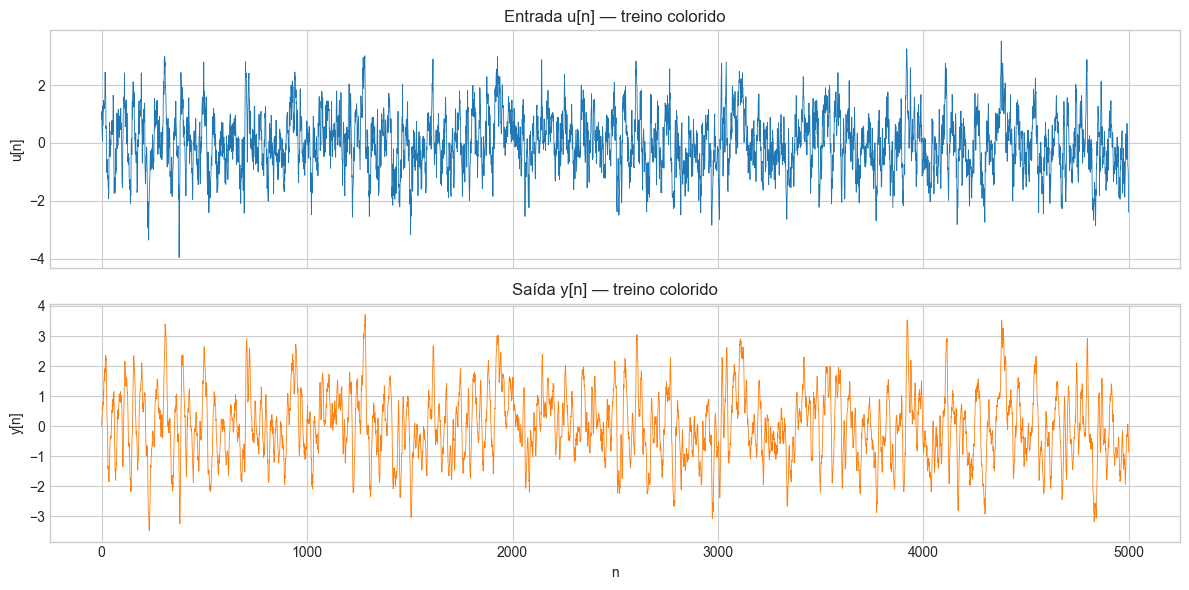

In [17]:
n_b, u_b, y_b = load_dataset("dados_treino_colorido.csv")
print(f"Amostras: {len(n_b)}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(n_b, u_b, linewidth=0.6)
axes[0].set_ylabel("u[n]")
axes[0].set_title("Entrada u[n] — treino colorido")
axes[1].plot(n_b, y_b, linewidth=0.6, color="C1")
axes[1].set_ylabel("y[n]")
axes[1].set_xlabel("n")
axes[1].set_title("Saída y[n] — treino colorido")
plt.tight_layout()
plt.show()

## B.1 — Análise temporal e espectral

### B.1.1 Média, variância e autocorrelação de u[n] e y[n]

In [18]:
stats_b = pd.DataFrame(
    {
        "sinal": ["u[n]", "y[n]"],
        "média": [u_b.mean(), y_b.mean()],
        "variância": [u_b.var(), y_b.var()],
        "desvio padrão": [u_b.std(), y_b.std()],
        "mínimo": [u_b.min(), y_b.min()],
        "máximo": [u_b.max(), y_b.max()],
    }
)
stats_b

,sinal,média,variância,desvio padrão,mínimo,máximo
0,u[n],0.006368,1.000000,1.000000,-3.960287,3.513943
1,y[n],0.010928,1.277091,1.130085,-3.475678,3.716581


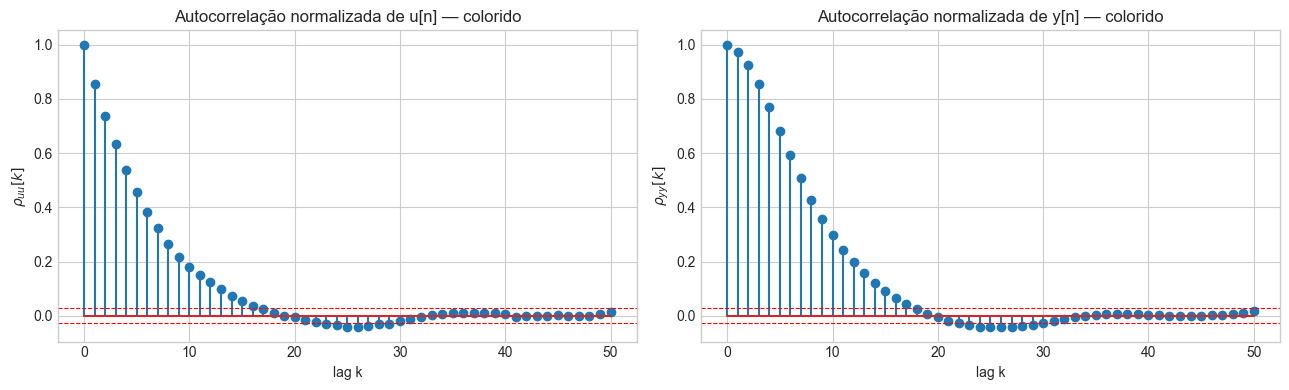

Banda de confiança ~95%: +/- 0.0277
u[n]: fração de |rho| (lags>=1) acima da banda: 0.460
y[n]: fração de |rho| (lags>=1) acima da banda: 0.480


In [19]:
r_uu_b = biased_autocorr(u_b, MAX_LAG)
r_yy_b = biased_autocorr(y_b, MAX_LAG)
rho_uu_b = r_uu_b / r_uu_b[0]
rho_yy_b = r_yy_b / r_yy_b[0]
conf_b = 1.96 / np.sqrt(len(u_b))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].stem(lags_pos, rho_uu_b)
axes[0].axhline(conf_b, color="r", ls="--", lw=0.8)
axes[0].axhline(-conf_b, color="r", ls="--", lw=0.8)
axes[0].set_title("Autocorrelação normalizada de u[n] — colorido")
axes[0].set_xlabel("lag k")
axes[0].set_ylabel(r"$\rho_{uu}[k]$")

axes[1].stem(lags_pos, rho_yy_b)
axes[1].axhline(conf_b, color="r", ls="--", lw=0.8)
axes[1].axhline(-conf_b, color="r", ls="--", lw=0.8)
axes[1].set_title("Autocorrelação normalizada de y[n] — colorido")
axes[1].set_xlabel("lag k")
axes[1].set_ylabel(r"$\rho_{yy}[k]$")
plt.tight_layout()
plt.show()

print(f"Banda de confiança ~95%: +/- {conf_b:.4f}")
print(f"u[n]: fração de |rho| (lags>=1) acima da banda: "
      f"{np.mean(np.abs(rho_uu_b[1:]) > conf_b):.3f}")
print(f"y[n]: fração de |rho| (lags>=1) acima da banda: "
      f"{np.mean(np.abs(rho_yy_b[1:]) > conf_b):.3f}")

**Leitura esperada:** diferente do caso branco, agora `u[n]` apresenta autocorrelação
**significativa** (muitos lags fora da banda), ou seja, é um sinal **colorido** com memória.
Isso já antecipa que a relação $R_{yu}[k] \propto h[k]$ (válida só para entrada branca)
**não** vale mais aqui.

### B.1.2 Correlação cruzada entre u[n] e y[n]

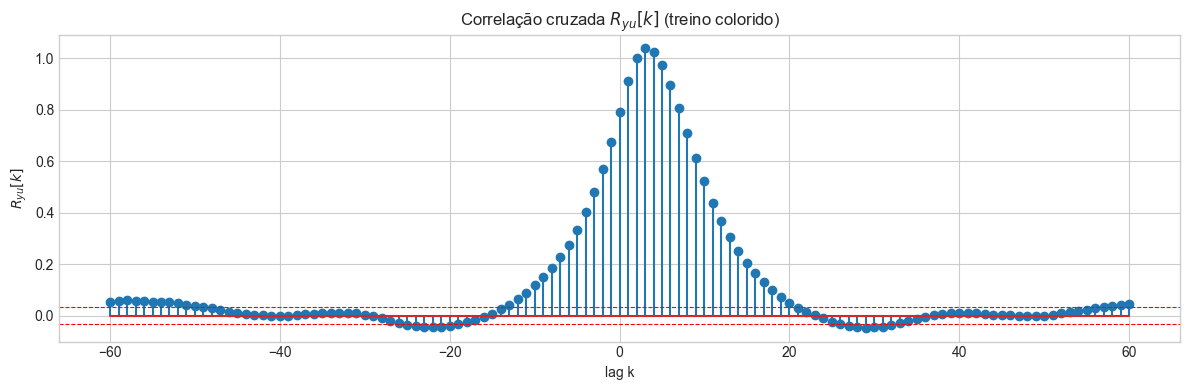

Pico de |R_yu| no lag k = 3
Com entrada colorida, R_yu[k] != sigma_u^2 * h[k]: a correlação cruzada fica
'borrada' pela autocorrelação da entrada e não estima diretamente a resp. ao impulso.


In [20]:
lags_cc_b, r_yu_b = biased_crosscorr(u_b, y_b, CC_LAG)

plt.figure(figsize=(12, 4))
plt.stem(lags_cc_b, r_yu_b)
plt.axhline(conf_b * u_b.std() * y_b.std(), color="r", ls="--", lw=0.8)
plt.axhline(-conf_b * u_b.std() * y_b.std(), color="r", ls="--", lw=0.8)
plt.title(r"Correlação cruzada $R_{yu}[k]$ (treino colorido)")
plt.xlabel("lag k")
plt.ylabel(r"$R_{yu}[k]$")
plt.tight_layout()
plt.show()

k_peak_b = lags_cc_b[np.argmax(np.abs(r_yu_b))]
print(f"Pico de |R_yu| no lag k = {k_peak_b}")
print("Com entrada colorida, R_yu[k] != sigma_u^2 * h[k]: a correlação cruzada fica")
print("'borrada' pela autocorrelação da entrada e não estima diretamente a resp. ao impulso.")

### B.1.3 PSD de u[n] e y[n] (método de Welch)

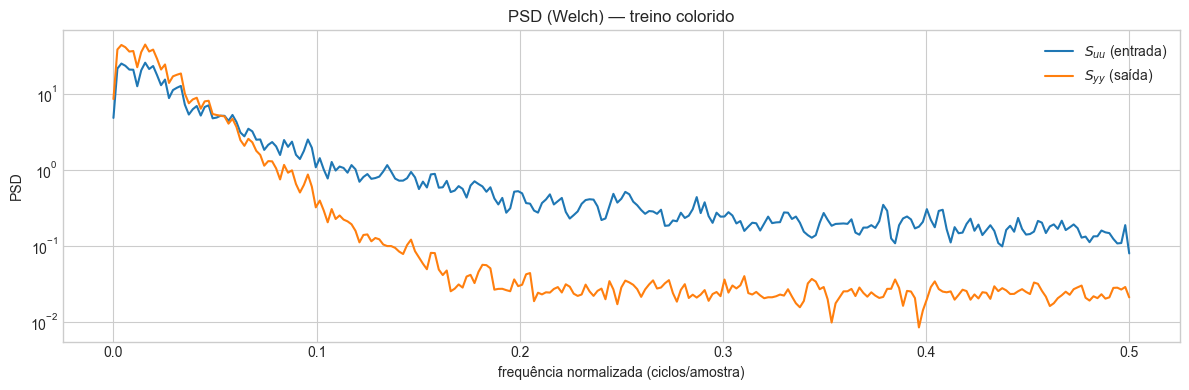

S_uu plana? razão max/min = 326.54 (quanto maior, mais colorida a entrada)


In [21]:
f_u_b, Puu_b = signal.welch(u_b, fs=FS, nperseg=NPERSEG)
f_y_b, Pyy_b = signal.welch(y_b, fs=FS, nperseg=NPERSEG)

plt.figure(figsize=(12, 4))
plt.semilogy(f_u_b, Puu_b, label=r"$S_{uu}$ (entrada)")
plt.semilogy(f_y_b, Pyy_b, label=r"$S_{yy}$ (saída)", color="C1")
plt.title("PSD (Welch) — treino colorido")
plt.xlabel("frequência normalizada (ciclos/amostra)")
plt.ylabel("PSD")
plt.legend()
plt.tight_layout()
plt.show()

print(f"S_uu plana? razão max/min = {Puu_b.max() / Puu_b.min():.2f} "
      f"(quanto maior, mais colorida a entrada)")

**Leitura esperada:** `S_uu` **não** é plana — a energia da entrada está concentrada
em uma faixa (tipicamente baixas frequências). Onde `S_uu` é pequena, o sistema é
pouco excitado e a estimação fica menos confiável.

### B.1.4 Espectro cruzado entre u[n] e y[n]

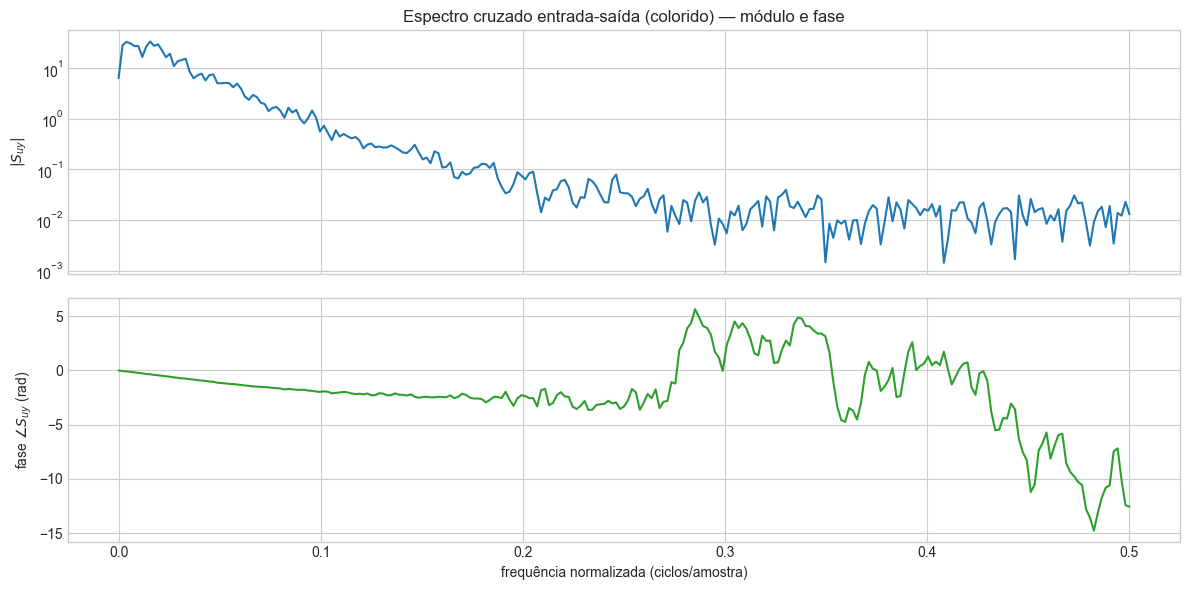

In [22]:
f_c_b, Suy_b = signal.csd(u_b, y_b, fs=FS, nperseg=NPERSEG)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].semilogy(f_c_b, np.abs(Suy_b))
axes[0].set_ylabel(r"$|S_{uy}|$")
axes[0].set_title("Espectro cruzado entrada-saída (colorido) — módulo e fase")
axes[1].plot(f_c_b, np.unwrap(np.angle(Suy_b)), color="C2")
axes[1].set_ylabel(r"fase $\angle S_{uy}$ (rad)")
axes[1].set_xlabel("frequência normalizada (ciclos/amostra)")
plt.tight_layout()
plt.show()

### B.1.5 Coerência entrada-saída

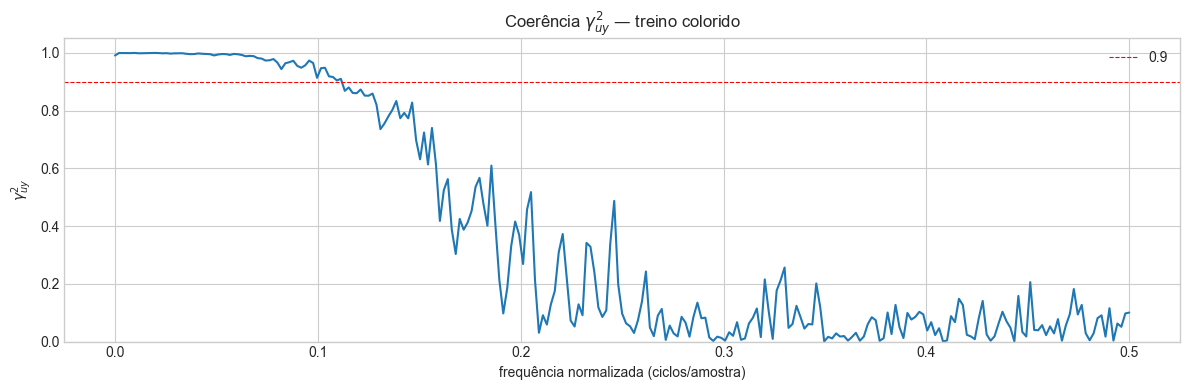

Coerência média: 0.380
Fração de frequências com coerência > 0.9: 0.226


In [23]:
f_coh_b, coh_b = signal.coherence(u_b, y_b, fs=FS, nperseg=NPERSEG)

plt.figure(figsize=(12, 4))
plt.plot(f_coh_b, coh_b)
plt.axhline(0.9, color="r", ls="--", lw=0.8, label="0.9")
plt.title(r"Coerência $\gamma_{uy}^2$ — treino colorido")
plt.xlabel("frequência normalizada (ciclos/amostra)")
plt.ylabel(r"$\gamma_{uy}^2$")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Coerência média: {coh_b.mean():.3f}")
print(f"Fração de frequências com coerência > 0.9: {np.mean(coh_b > 0.9):.3f}")

## B.2 — Comparação com o caso `dados_treino_branco.csv`

Reaproveitamos as variáveis do tópico A (sufixo `_a` / sem sufixo) para comparar
diretamente entrada branca vs. colorida.

In [24]:
comp = pd.DataFrame(
    {
        "métrica": [
            "média u", "variância u", "média y", "variância y",
            "frac. autocorr. u fora da banda", "razão PSD u (max/min)",
            "coerência média", "frac. coerência > 0.9",
        ],
        "branco": [
            u_a.mean(), u_a.var(), y_a.mean(), y_a.var(),
            np.mean(np.abs(rho_uu[1:]) > conf), Puu.max() / Puu.min(),
            coh.mean(), np.mean(coh > 0.9),
        ],
        "colorido": [
            u_b.mean(), u_b.var(), y_b.mean(), y_b.var(),
            np.mean(np.abs(rho_uu_b[1:]) > conf_b), Puu_b.max() / Puu_b.min(),
            coh_b.mean(), np.mean(coh_b > 0.9),
        ],
    }
)
comp.round(4)

,métrica,branco,colorido
0,média u,-0.0321,0.0064
1,variância u,0.9888,1.0000
2,média y,-0.0434,0.0109
3,variância y,0.2313,1.2771
4,frac. autocorr. u fora da banda,0.0400,0.4600
5,razão PSD u (max/min),13.0147,326.5445
6,coerência média,0.5844,0.3804
7,frac. coerência > 0.9,0.3852,0.2257


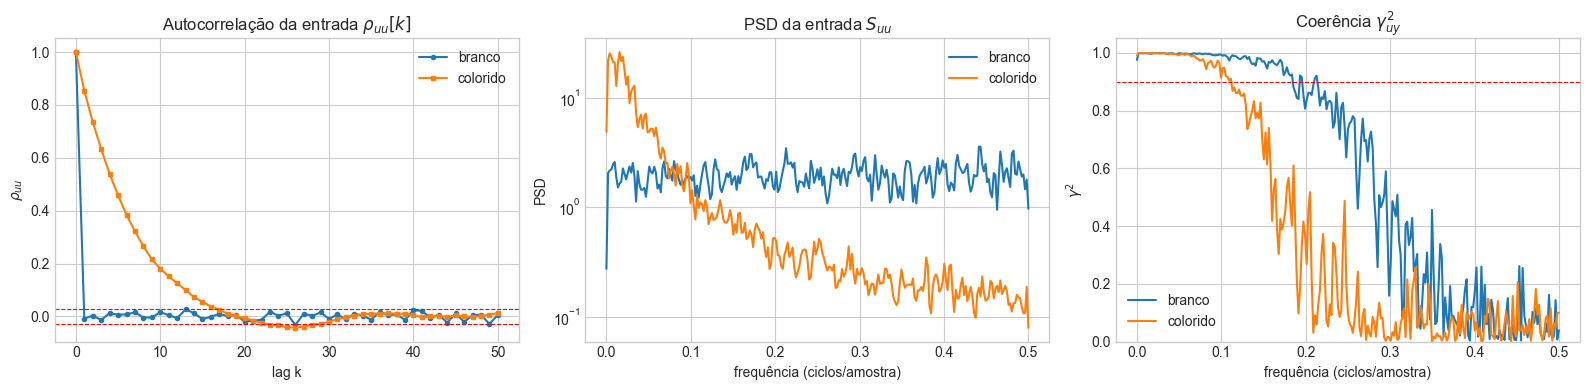

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Autocorrelação da entrada
axes[0].plot(lags_pos, rho_uu, "C0o-", label="branco", ms=3)
axes[0].plot(lags_pos, rho_uu_b, "C1s-", label="colorido", ms=3)
axes[0].axhline(conf, color="r", ls="--", lw=0.8)
axes[0].axhline(-conf, color="r", ls="--", lw=0.8)
axes[0].set_title(r"Autocorrelação da entrada $\rho_{uu}[k]$")
axes[0].set_xlabel("lag k")
axes[0].set_ylabel(r"$\rho_{uu}$")
axes[0].legend()

# PSD da entrada
axes[1].semilogy(f_u, Puu, label="branco")
axes[1].semilogy(f_u_b, Puu_b, label="colorido")
axes[1].set_title(r"PSD da entrada $S_{uu}$")
axes[1].set_xlabel("frequência (ciclos/amostra)")
axes[1].set_ylabel("PSD")
axes[1].legend()

# Coerência
axes[2].plot(f_coh, coh, label="branco")
axes[2].plot(f_coh_b, coh_b, label="colorido")
axes[2].axhline(0.9, color="r", ls="--", lw=0.8)
axes[2].set_title(r"Coerência $\gamma_{uy}^2$")
axes[2].set_xlabel("frequência (ciclos/amostra)")
axes[2].set_ylabel(r"$\gamma^2$")
axes[2].set_ylim(0, 1.05)
axes[2].legend()

plt.tight_layout()
plt.show()

In [26]:
# Coerência e excitação da entrada por faixa de frequência
bands = [(0.0, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.4), (0.4, 0.5)]
rows = []
for lo, hi in bands:
    mw = (f_coh >= lo) & (f_coh < hi)
    mb = (f_coh_b >= lo) & (f_coh_b < hi)
    msu_w = (f_u >= lo) & (f_u < hi)
    msu_b = (f_u_b >= lo) & (f_u_b < hi)
    rows.append(
        {
            "faixa": f"[{lo:.1f}, {hi:.1f})",
            "coh branco": coh[mw].mean(),
            "coh colorido": coh_b[mb].mean(),
            "Suu branco": Puu[msu_w].mean(),
            "Suu colorido": Puu_b[msu_b].mean(),
        }
    )
pd.DataFrame(rows).round(4)

,faixa,coh branco,coh colorido,Suu branco,Suu colorido
0,"[0.0, 0.1)",0.9962,0.9858,1.9006,8.4200
1,"[0.1, 0.2)",0.9525,0.6438,1.9461,0.7465
2,"[0.2, 0.3)",0.7021,0.1394,2.0019,0.3248
3,"[0.3, 0.4)",0.2024,0.0659,1.9188,0.2024
4,"[0.4, 0.5)",0.0714,0.0604,2.0882,0.1696


## B.3 — Discussão: por que a identificação piora em faixas mal excitadas

**Pergunta:** por que a identificação pode piorar em algumas faixas de frequência quando
a entrada não excita adequadamente todo o espectro?

Para responder de forma concreta, identificamos um FIR **a partir dos dados coloridos**
e comparamos sua resposta em frequência com o modelo de referência obtido no **caso
branco** (tópico A), que serve como "verdade" porque foi estimado com excitação plena.

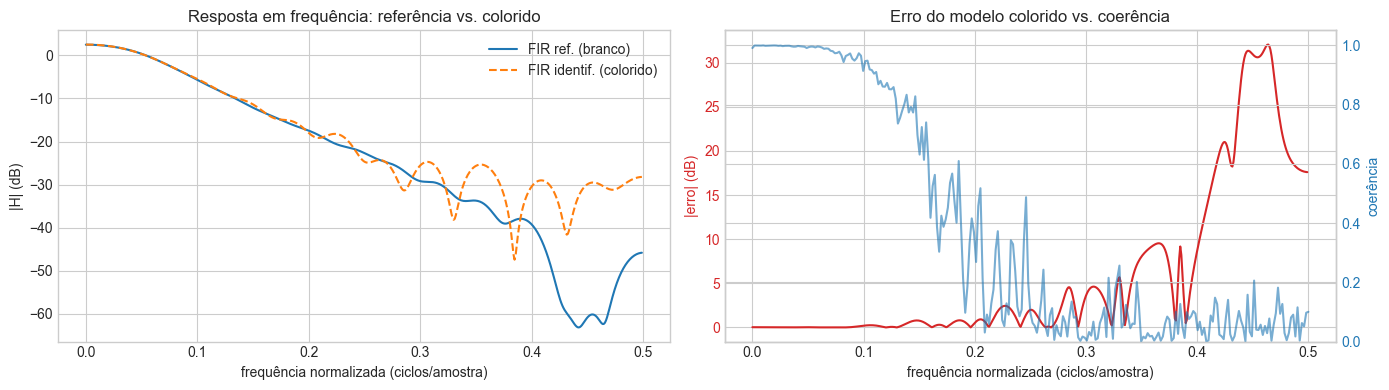

R² de treino (FIR colorido, no próprio conjunto): 0.99044
Distância relativa entre h colorido e h branco: 0.0458


,faixa,erro |H| médio (dB),coerência média
0,"[0.0, 0.1)",0.026,0.986
1,"[0.1, 0.2)",0.335,0.644
2,"[0.2, 0.3)",1.505,0.139
3,"[0.3, 0.4)",5.365,0.066
4,"[0.4, 0.5)",22.409,0.060


In [27]:
# FIR identificado a partir dos dados COLORIDOS (mesma ordem M do tópico A)
h_fir_b, _, r2_b_train = fit_eval_skip(u_b, y_b, M)

# h_fir (tópico A) é o modelo de referência, estimado com entrada branca
w_ref, H_ref = signal.freqz(h_fir, worN=512, fs=FS)
w_col, H_col = signal.freqz(h_fir_b, worN=512, fs=FS)

err_db = 20 * np.log10(np.abs(H_col)) - 20 * np.log10(np.abs(H_ref))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Resposta em frequência: referência (branco) vs identificada (colorido)
axes[0].plot(w_ref, 20 * np.log10(np.abs(H_ref)), label="FIR ref. (branco)", lw=1.5)
axes[0].plot(w_col, 20 * np.log10(np.abs(H_col)), label="FIR identif. (colorido)", ls="--")
axes[0].set_title("Resposta em frequência: referência vs. colorido")
axes[0].set_xlabel("frequência normalizada (ciclos/amostra)")
axes[0].set_ylabel("|H| (dB)")
axes[0].legend()
# Erro de módulo + coerência sobreposta
ax2 = axes[1]
ax2.plot(w_col, np.abs(err_db), color="C3", label="|erro de módulo| (dB)")
ax2.set_xlabel("frequência normalizada (ciclos/amostra)")
ax2.set_ylabel("|erro| (dB)", color="C3")
ax2.tick_params(axis="y", labelcolor="C3")
ax2.set_title("Erro do modelo colorido vs. coerência")
ax2b = ax2.twinx()
ax2b.plot(f_coh_b, coh_b, color="C0", alpha=0.6, label="coerência")
ax2b.set_ylabel("coerência", color="C0")
ax2b.tick_params(axis="y", labelcolor="C0")
ax2b.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Erro de |H| por faixa de frequência
rows = []
for lo, hi in bands:
    m = (w_col >= lo) & (w_col < hi)
    mc = (f_coh_b >= lo) & (f_coh_b < hi)
    rows.append(
        {
            "faixa": f"[{lo:.1f}, {hi:.1f})",
            "erro |H| médio (dB)": np.mean(np.abs(err_db[m])),
            "coerência média": coh_b[mc].mean(),
        }
    )
print(f"R² de treino (FIR colorido, no próprio conjunto): {r2_b_train:.5f}")
print(f"Distância relativa entre h colorido e h branco: "
      f"{np.linalg.norm(h_fir_b - h_fir) / np.linalg.norm(h_fir):.4f}")
pd.DataFrame(rows).round(3)

In [28]:
# O R² alto pode mascarar o problema: testamos os dois modelos na validação branca
def r2_on(h, u, y, skip):
    y_hat = np.convolve(u, h)[: len(u)]
    e = y[skip:] - y_hat[skip:]
    return 1 - np.sum(e ** 2) / np.sum((y[skip:] - y[skip:].mean()) ** 2)

r2_ref_val = r2_on(h_fir, u_v, y_v, M)
r2_col_val = r2_on(h_fir_b, u_v, y_v, M)
print(f"Modelo de referência (branco)  -> R² na validação branca = {r2_ref_val:.4f}")
print(f"Modelo identificado (colorido) -> R² na validação branca = {r2_col_val:.4f}")
print()
print("Apesar do R² parecido, a resposta em frequência do modelo colorido é")
print("grosseiramente errada nas altas frequências (ver erro em dB por faixa):")
print("o R² é dominado pela energia de baixa frequência e mascara o erro onde")
print("a entrada não excitou o sistema.")

Modelo de referência (branco)  -> R² na validação branca = 0.9901
Modelo identificado (colorido) -> R² na validação branca = 0.9886

Apesar do R² parecido, a resposta em frequência do modelo colorido é
grosseiramente errada nas altas frequências (ver erro em dB por faixa):
o R² é dominado pela energia de baixa frequência e mascara o erro onde
a entrada não excitou o sistema.


### Interpretação

Os resultados confirmam que a identificação **degrada justamente nas faixas onde a
entrada não excita o sistema**, e a degradação acompanha de perto a queda da coerência.

**1. Excitação e relação sinal-ruído por frequência.**
A estimativa da resposta em frequência depende de $\hat{S}_{uu}(e^{j\omega})$ no denominador:
$\hat{H}(e^{j\omega}) = \hat{S}_{yu}/\hat{S}_{uu}$. Onde a entrada colorida concentra
energia (baixas frequências), $\hat{S}_{uu}$ é grande, o sinal de saída devido à entrada
domina o ruído de medição e a estimativa é confiável. Onde a entrada quase não excita
(altas frequências), $\hat{S}_{uu}$ é pequeno: a saída ali é essencialmente ruído, a
razão sinal-ruído despenca e dividir por um número pequeno **amplifica o erro**.

**2. A coerência antecipa a faixa confiável.**
A coerência caiu abaixo de 0.9 já em torno de $f \approx 0.11$ (contra $\approx 0.2$ no
caso branco). O erro de módulo do modelo identificado com dados coloridos é desprezível
na banda excitada (~0,03 dB em $[0,\,0.1)$) e cresce monotonicamente até dezenas de dB
na banda não excitada ($\approx 22$ dB em $[0.4,\,0.5)$). Ou seja, **a coerência funciona
como um "mapa de confiabilidade"** da estimação ao longo da frequência.

**3. A correlação cruzada deixa de revelar $h[k]$.**
Com entrada branca vale $R_{yu}[k] = \sigma_u^2\,h[k]$; com entrada colorida,
$R_{yu}[k] = (h * R_{uu})[k]$, isto é, a resposta ao impulso aparece **convoluída com a
autocorrelação da entrada** (verificado em B.1.2). A entrada colorida "borra" a informação
e impede a leitura direta de $h[k]$ pela correlação cruzada.

**4. O R² global pode mascarar o problema.**
O FIR identificado com dados coloridos atinge $R^2 \approx 0.99$ no próprio conjunto e
ainda vai bem na validação branca — porque essas métricas são dominadas pela energia de
baixa frequência, onde houve excitação. Apesar disso, sua resposta em frequência é
**grosseiramente incorreta** nas altas frequências. Conclusão prática: validar um modelo
apenas pelo erro temporal/R² é insuficiente; é preciso checar coerência e resposta em
frequência para saber **em que faixas** o modelo é confiável.

**Resumo.** A entrada colorida só "ilumina" parte do espectro. Fora da banda excitada,
faltam dados informativos: a estimativa fica mal condicionada, ruidosa e enviesada, e a
coerência sinaliza exatamente onde isso ocorre. Para identificar bem todo o espectro,
o ideal é uma entrada de banda larga (idealmente branca) ou um projeto de excitação que
cubra as frequências de interesse.